## 🔗 Topologies

**Concepts:** [Network topologies](../problem.md#network-topologies) **Reference:** [Validation](../reference/validation.md) **Network/Router API:** [🔗 Topologies](hi30_topologies.ipynb)

The three electrical topologies _OptiWindNet_ supports — **branched**, **radial** and **ringed** — are defined in [Network topologies](../problem.md#network-topologies), and the checks used below are described in [Validation](../reference/validation.md).

This notebook builds a warm start for each topology and solves the corresponding MILP model directly through [solver_factory()](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.solver_factory).

### Warm-starts, solving, and validation

[constructor()](../autoapi/optiwindnet/heuristics/index.rst#optiwindnet.heuristics.constructor) can generate a warm start for all three topology types through `method`. `G_from_S(S, A)` turns a topology into a tentative physical graph, and [PathFinder(...).create_detours()](../autoapi/optiwindnet/pathfinding/index.rst#optiwindnet.pathfinding.PathFinder.create_detours) turns that into a routeset.

In [1]:
from optiwindnet.heuristics import constructor
from optiwindnet.importer import load_repository
from optiwindnet.interarraylib import validate_routeset, validate_topology
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.MILP import ModelOptions, solver_factory
from optiwindnet.svg import svgplot

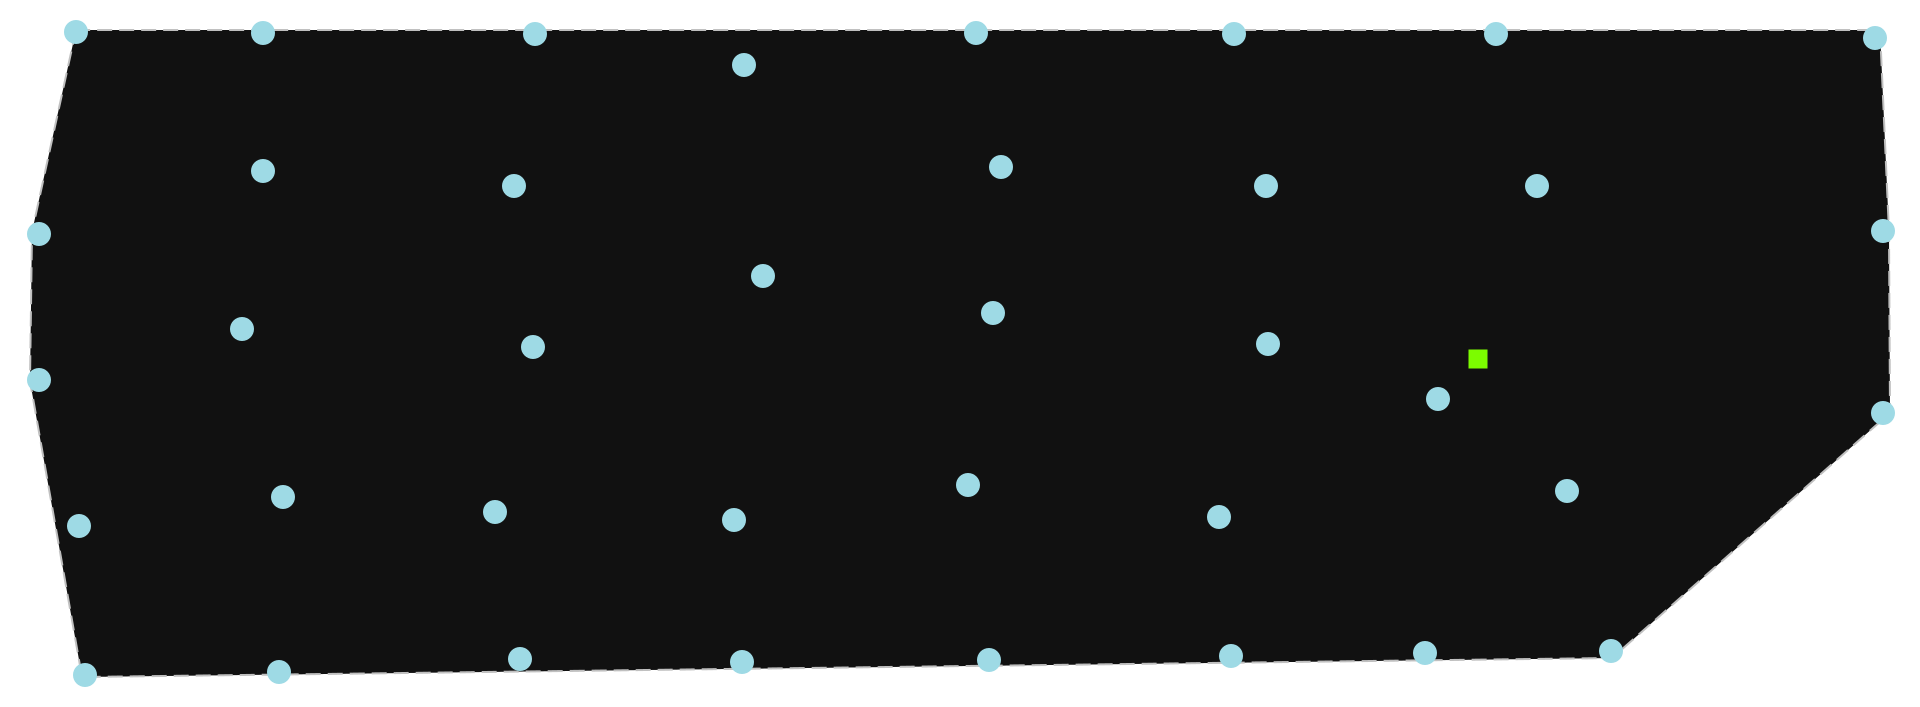

In [2]:
locations = load_repository()
L = locations.kaskasi
P, A = make_planar_embedding(L)
capacity = 5
svgplot(L)

In [3]:
solver = solver_factory('highs')

### The three topology types

The following cell is deliberately shared by the solver examples below: it plots the tentative physical graph corresponding to each topology. The link geometry is still direct at this stage.

### Warm-starts

[constructor()](../autoapi/optiwindnet/heuristics/index.rst#optiwindnet.heuristics.constructor) can generate warmstarts for all three topology types through `method`.

In [4]:
S_branched = constructor(A, capacity=capacity, method='rootlust')

In [5]:
S_radial = constructor(A, capacity=capacity, method='radial_EW')

In [6]:
S_ring = constructor(A, capacity=capacity, method='ringed')

[validate_topology()](../autoapi/optiwindnet/interarraylib/index.rst#optiwindnet.interarraylib.validate_topology) checks electrical feasibility — see [Electrical feasibility](../reference/validation.md#electrical-feasibility).

In [7]:
validate_topology(S_ring)

[]

### Branched

In [8]:
# branched
solver.set_problem(P, A, capacity, model_options=ModelOptions(), warmstart=S_branched)
solver.solve(time_limit=30, mip_gap=1e-3)

SolutionInfo(runtime=30.048882961273193, bound=37393.79241725747, objective=37738.02716249274, relgap=0.009121694246311818, termination='maxTimeLimit')

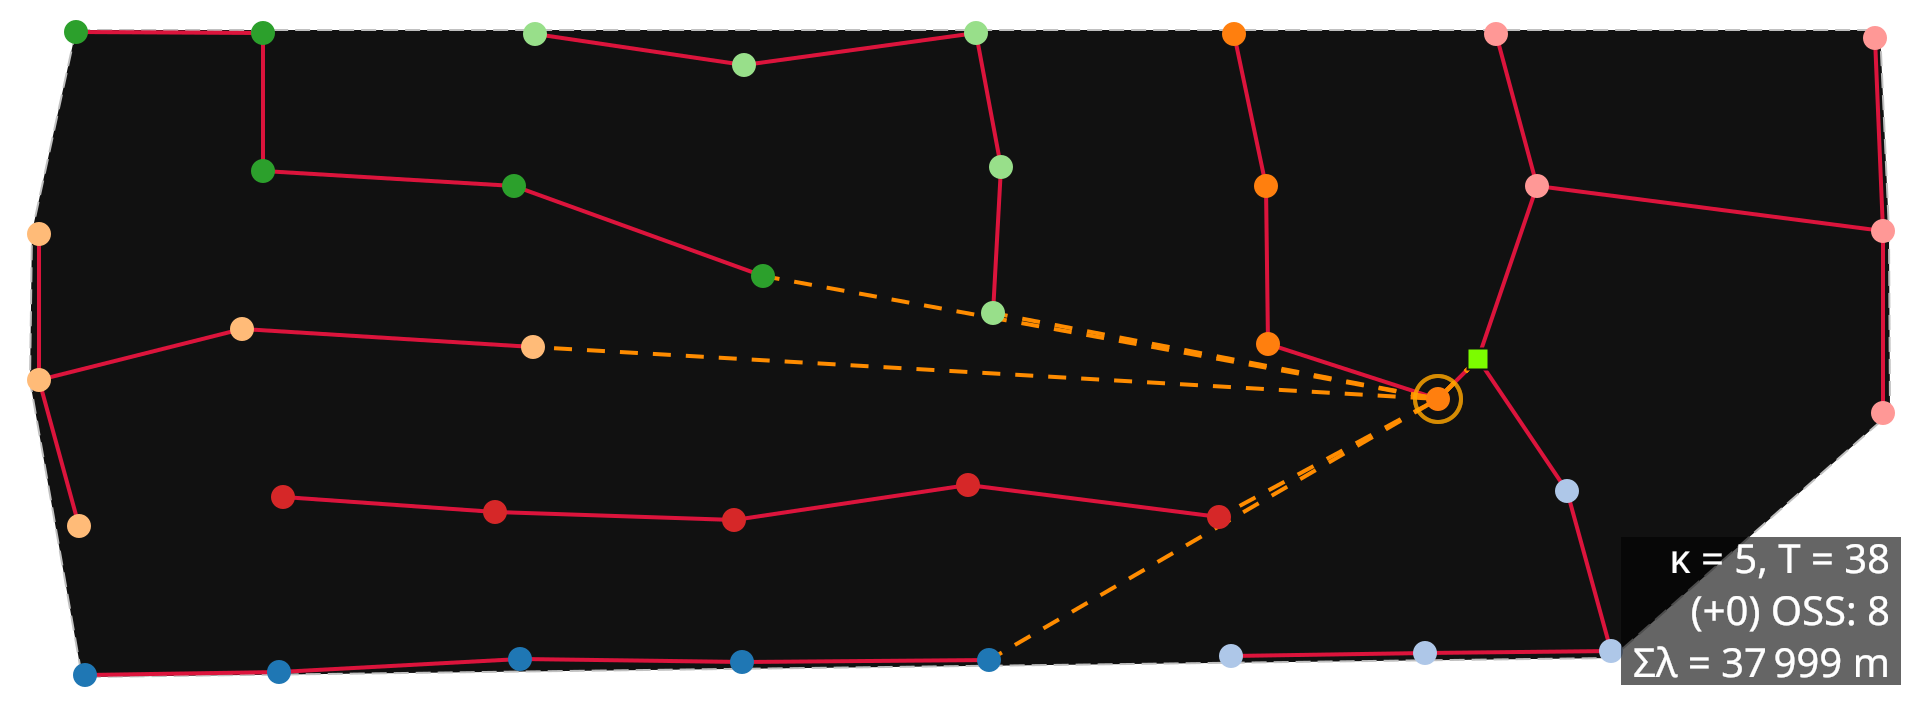

In [9]:
S, G = solver.get_solution()
svgplot(G)

### Radial

In [10]:
# radial
solver.set_problem(
    P, A, capacity, model_options=ModelOptions(topology='radial'), warmstart=S_radial
)
solver.solve(time_limit=30, mip_gap=1e-3)

SolutionInfo(runtime=30.03814196586609, bound=37571.75630978712, objective=37915.4046985737, relgap=0.009063555869140205, termination='maxTimeLimit')

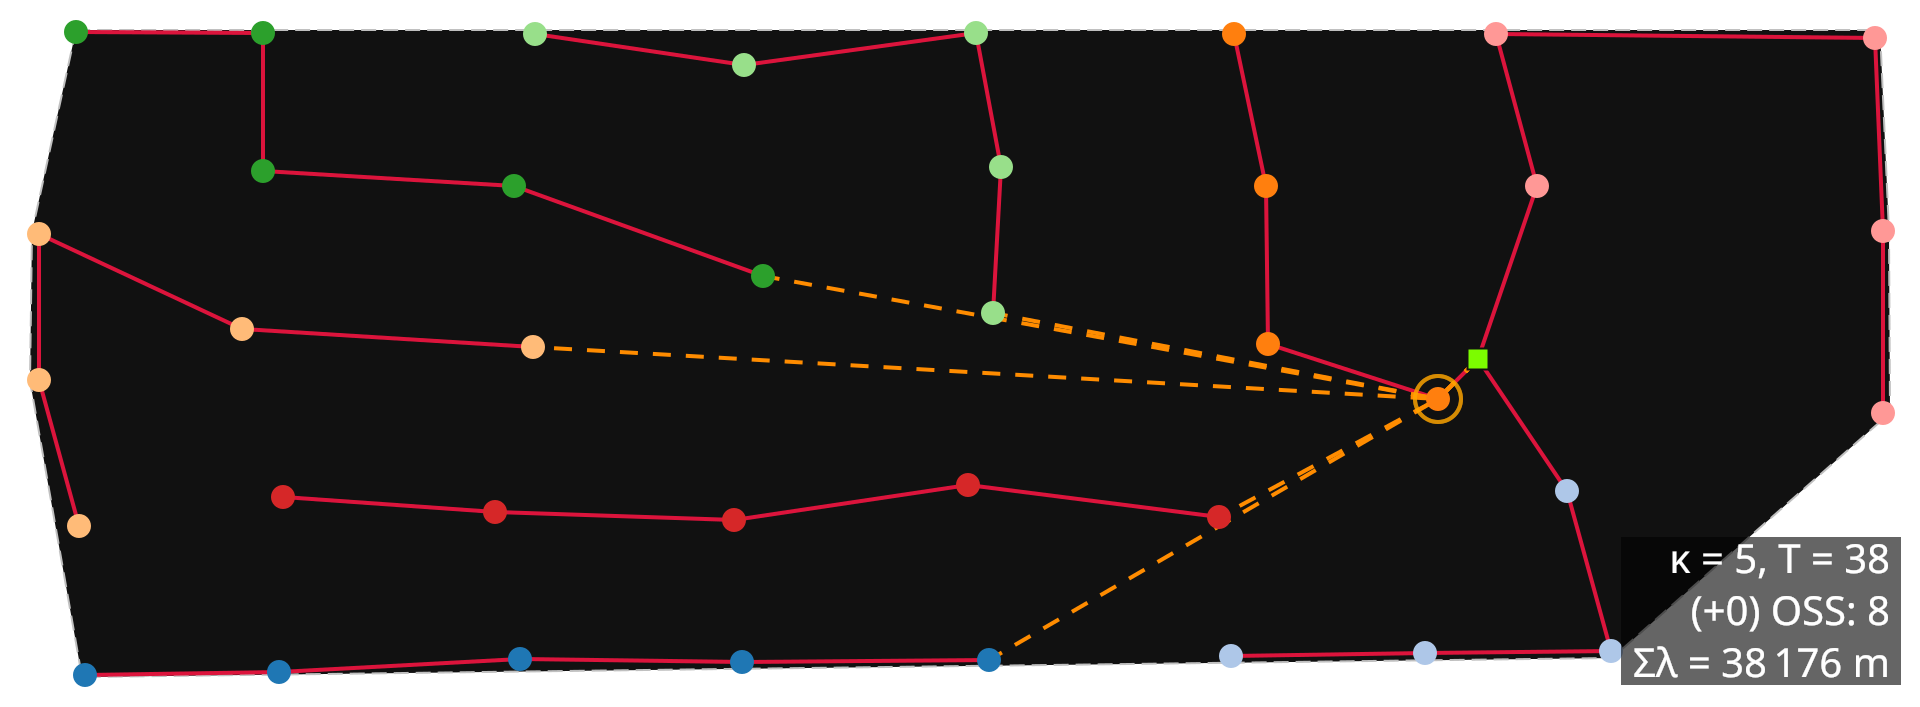

In [11]:
S, G = solver.get_solution()
svgplot(G)

### Ringed

In [12]:
# ringed
solver.set_problem(
    P, A, capacity, model_options=ModelOptions(topology='ringed'), warmstart=S_ring
)
solver.solve(time_limit=60, mip_gap=1e-3)

SolutionInfo(runtime=60.05387330055237, bound=40136.27818010816, objective=41966.38628386653, relgap=0.043608903835066104, termination='maxTimeLimit')

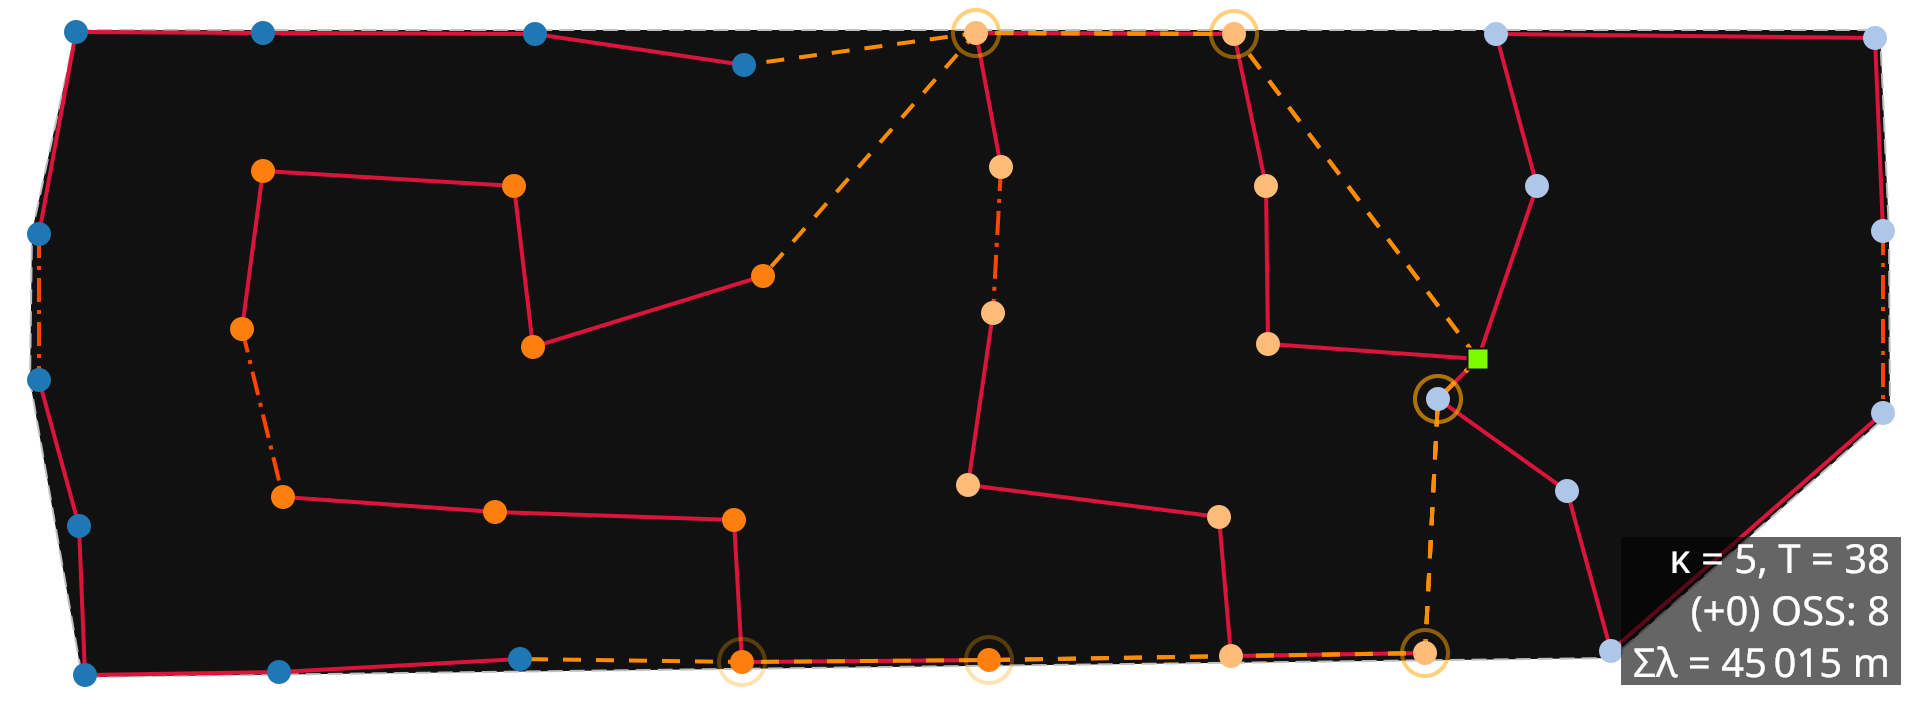

In [13]:
S, G = solver.get_solution()
svgplot(G)

[validate_routeset()](../autoapi/optiwindnet/interarraylib/index.rst#optiwindnet.interarraylib.validate_routeset) checks the routeset and calls [validate_topology()](../autoapi/optiwindnet/interarraylib/index.rst#optiwindnet.interarraylib.validate_topology) internally. For crossing detection, see [Geometric feasibility](../reference/validation.md#geometric-feasibility).

In [14]:
validate_routeset(G)

[]